# Week 5 — LQR, Kalman Filtering, and MPC

This notebook puts the three Week 5 ideas next to each other on small models.

- **LQR:** choose feedback gains by minimizing state error + control effort.
- **Kalman filter:** estimate the state from a model plus noisy measurements.
- **MPC:** optimize a future control sequence while enforcing constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are, expm

## 1. LQR

For $\\dot x=Ax+Bu$, LQR minimizes

$$J=\\int_0^\\infty (x^TQx+u^TRu)dt$$

and produces $u=-Kx$. Bigger $Q$ means state error is more expensive; bigger $R$ means actuation is more expensive.

K = [[3.66923269 0.65952567]]
open-loop poles = [-1.5  -0.25]
closed-loop poles = [-5.23927476 -0.41079192]


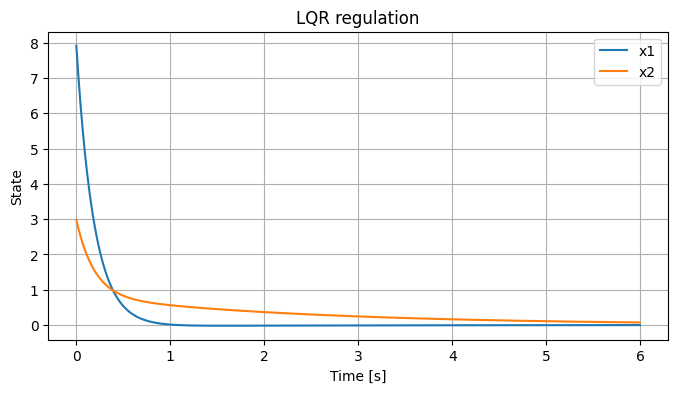

In [2]:
A = np.array([[-1.5, 0.4],[0.0,-0.25]])
B = np.array([[1.0],[0.35]])
Q = np.diag([20.0, 2.0])
R = np.array([[0.8]])
P = solve_continuous_are(A,B,Q,R)
K = np.linalg.inv(R) @ B.T @ P
print("K =", K)
print("open-loop poles =", np.linalg.eigvals(A))
print("closed-loop poles =", np.linalg.eigvals(A-B@K))

dt=0.002
t=np.arange(0,6,dt)
x=np.array([8.0,3.0])
X=[]; U=[]
for _ in t:
    u=float((-K@x).item())
    x=x+(A@x+B[:,0]*u)*dt
    X.append(x.copy()); U.append(u)
X=np.array(X)
plt.figure(figsize=(8,4))
plt.plot(t,X[:,0],label='x1')
plt.plot(t,X[:,1],label='x2')
plt.xlabel('Time [s]'); plt.ylabel('State'); plt.title('LQR regulation'); plt.legend(); plt.grid(True); plt.show()

## 2. Kalman filter

The estimator alternates between **prediction** from the model and **correction** from the measurement residual.

$$\\hat x^-_{k+1}=A_d\\hat x_k+B_du_k$$

$$\\hat x_{k+1}=\\hat x^-_{k+1}+L(y-C\\hat x^-_{k+1})$$

Here only the first state is measured; the second must be reconstructed from the dynamics.

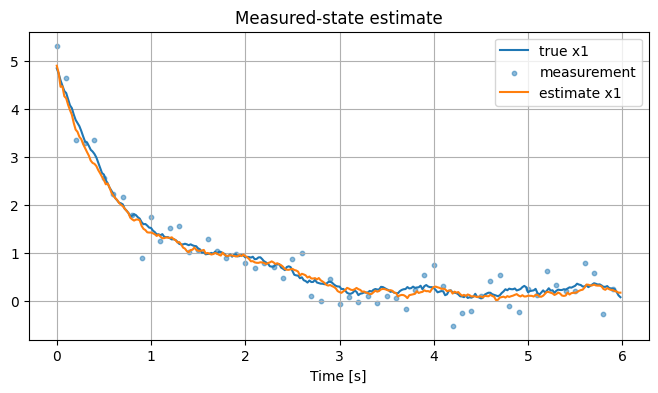

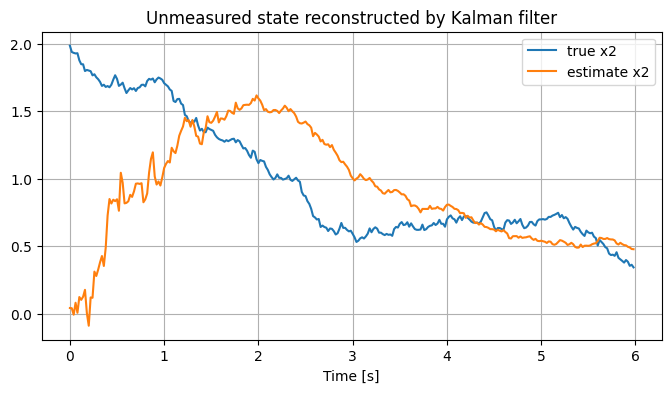

In [3]:
dtk=0.02
Ad=expm(A*dtk)
Bd=np.linalg.solve(A,(Ad-np.eye(2)))@B
C=np.array([[1.0,0.0]])
Qn=np.diag([1e-3,5e-4])
Rn=np.array([[0.08]])
rng=np.random.default_rng(4)
xtrue=np.array([5.0,2.0]); xhat=np.zeros(2); Pcov=np.eye(2)
TRUE=[]; EST=[]; MEAS=[]
for _ in range(300):
    xtrue=Ad@xtrue+rng.multivariate_normal([0,0],Qn)
    y=float((C@xtrue).item()+rng.normal(0,np.sqrt(Rn[0,0])))
    xpred=Ad@xhat
    Ppred=Ad@Pcov@Ad.T+Qn
    S=C@Ppred@C.T+Rn
    L=Ppred@C.T@np.linalg.inv(S)
    xhat=xpred+(L@(np.array([y])-C@xpred)).ravel()
    Pcov=(np.eye(2)-L@C)@Ppred
    TRUE.append(xtrue.copy()); EST.append(xhat.copy()); MEAS.append(y)
TRUE=np.array(TRUE); EST=np.array(EST); tk=np.arange(len(TRUE))*dtk
plt.figure(figsize=(8,4))
plt.plot(tk,TRUE[:,0],label='true x1')
plt.scatter(tk[::5],np.array(MEAS)[::5],s=10,alpha=.5,label='measurement')
plt.plot(tk,EST[:,0],label='estimate x1')
plt.xlabel('Time [s]'); plt.title('Measured-state estimate'); plt.legend(); plt.grid(True); plt.show()
plt.figure(figsize=(8,4))
plt.plot(tk,TRUE[:,1],label='true x2')
plt.plot(tk,EST[:,1],label='estimate x2')
plt.xlabel('Time [s]'); plt.title('Unmeasured state reconstructed by Kalman filter'); plt.legend(); plt.grid(True); plt.show()

## 3. MPC

MPC predicts forward over a finite horizon, optimizes candidate control actions, applies only the **first** action, then repeats.

The important extra capability is explicit constraints. Below we use a tiny brute-force optimizer so the mechanism is visible rather than hidden inside a solver.

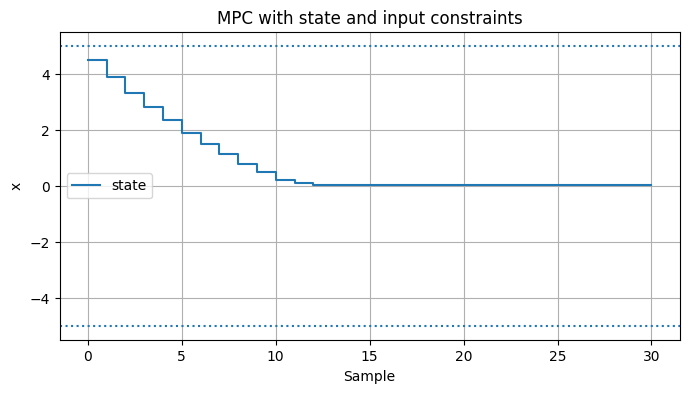

maximum |u| = 1.0


In [4]:
from itertools import product

a,b=0.92,0.25
u_choices=np.linspace(-1.0,1.0,9)
horizon=4
q,r=4.0,0.3

def mpc_action(x0):
    best_cost=np.inf; best_u0=0.0
    for seq in product(u_choices, repeat=horizon):
        x=x0; cost=0.0; feasible=True
        for u in seq:
            x=a*x+b*u
            if abs(x)>5.0:
                feasible=False; break
            cost += q*x*x+r*u*u
        if feasible and cost<best_cost:
            best_cost=cost; best_u0=seq[0]
    return best_u0

x=4.5; X=[x]; U=[]
for _ in range(30):
    u=mpc_action(x)
    x=a*x+b*u
    X.append(x); U.append(u)
plt.figure(figsize=(8,4))
plt.step(range(len(X)),X,where='post',label='state')
plt.axhline(5,linestyle=':'); plt.axhline(-5,linestyle=':')
plt.xlabel('Sample'); plt.ylabel('x'); plt.title('MPC with state and input constraints'); plt.legend(); plt.grid(True); plt.show()
print('maximum |u| =',max(abs(np.array(U))))

## Hybrid-electric control stack

A useful mental map is:

**fast inner loops** → PI/current/torque control  
**outer regulation** → PI or LQR for speed/power  
**state estimation** → Kalman filter  
**constraint-heavy supervisory control** → MPC

So Week 5 is really: **estimate the state → choose the best action → repeat**.